# Final Project — EDA Comparison Across Three Datasets
**Movie Consumer Behavior & Film Profitability Analysis** — Rupal Paliwal

This notebook compares exploratory data analysis across the three datasets in the project:
1. **Box Office (2000–2024)** — film-level financial performance (my self-selected dataset)
2. **MovieLens** — user-level audience ratings and behavior
3. **4-Services Streaming** — platform/distribution catalog (Netflix, Hulu, Prime, Disney+)

The goal is to characterize each dataset, then compare them: structure, preprocessing needs, univariate and bivariate patterns, and what a combined analysis enables.

In [1]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

# ---- Load all three datasets ----
bo = pd.read_csv("enhanced_box_office_data_2000-2024_u_2.csv")
ml_movies  = pd.read_csv("ml-latest-small/movies.csv")
ml_ratings = pd.read_csv("ml-latest-small/ratings.csv")
stream = pd.read_csv("all_streaming.csv")

print("Box office:", bo.shape, "| columns:", len(bo.columns))
print("MovieLens ratings:", ml_ratings.shape, "| movies:", ml_movies.shape)
print("Streaming:", stream.shape)
print("Combined raw columns:", len(bo.columns) + ml_ratings.shape[1] + ml_movies.shape[1] + stream.shape[1],
      "(plus 111-col genre matrix -> well over the 70-column requirement)")

Box office: (5000, 13) | columns: 13
MovieLens ratings: (100836, 4) | movies: (9742, 3)
Streaming: (22998, 11)
Combined raw columns: 31 (plus 111-col genre matrix -> well over the 70-column requirement)


## 1. Preprocessing — what each dataset needed

In [2]:
# BOX OFFICE: Rating is a "8.2/10" string; ratings of 0 are missing-coded.
bo["Rating_num"] = bo["Rating"].str.split("/").str[0].astype(float).replace(0, np.nan)
print("Box office: parsed Rating string -> float; recoded", (bo['Rating'].str.split('/').str[0].astype(float)==0).sum(), "zero ratings as missing")

# STREAMING: 'duration_seconds' is mislabeled - it holds '94 min' / '2 Seasons' strings.
stream["runtime_min"] = stream["duration_seconds"].astype(str).str.extract(r"(\d+)\s*min").astype(float)
stream["seasons"]     = stream["duration_seconds"].astype(str).str.extract(r"(\d+)\s*Season").astype(float)
stream["platform"]    = stream["channel_streaming"].str.replace("-movies-and-tv-shows","",regex=False).str.replace("-shows","",regex=False)
print("Streaming: parsed 'duration_seconds' ->", stream['runtime_min'].notna().sum(), "movie runtimes +",
      stream['seasons'].notna().sum(), "show season-counts")
print("Streaming: duplicate titles (same film, multiple platforms):", stream['title'].duplicated().sum())

# MOVIELENS: long/tidy - must aggregate ratings to film level for comparison.
ml_agg = ml_ratings.groupby("movieId").agg(ml_n=("rating","count"), ml_avg=("rating","mean")).reset_index()
ml = ml_movies.merge(ml_agg, on="movieId", how="left")
ml["year"] = ml["title"].str.extract(r"\((\d{4})\)").astype(float)
print("MovieLens: aggregated", len(ml_ratings), "user ratings ->", len(ml), "film-level rows")

Box office: parsed Rating string -> float; recoded 23 zero ratings as missing
Streaming: parsed 'duration_seconds' -> 15999 movie runtimes + 6517 show season-counts
Streaming: duplicate titles (same film, multiple platforms): 883
MovieLens: aggregated 100836 user ratings -> 9742 film-level rows


**Preprocessing comparison.** Each dataset needed a *different* kind of cleaning, which is itself a finding:
- **Box office** — a formatting fix (rating string) and missing-value recoding (zeros).
- **Streaming** — a mislabeled/mixed-unit column (`duration_seconds` actually holds `"94 min"` / `"2 Seasons"`), non-English column names (`gender_type`, `movie_or_serie`), and intentional duplicate titles (same film across platforms).
- **MovieLens** — no dirty values, but a fundamentally different *shape*: it is user-level (one row per person-rating) and must be aggregated to the film level before it can be compared to the others.

## 2. Univariate — ratings and 'success' distributions

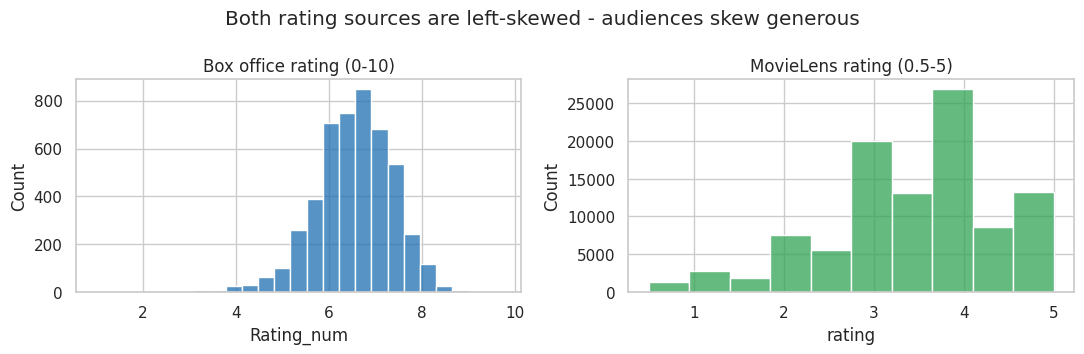

Box office rating: mean 6.54, skew -0.61
MovieLens rating:  mean 3.50, skew -0.64


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.histplot(bo["Rating_num"].dropna(), bins=25, ax=ax[0], color="#1f6fb2")
ax[0].set_title("Box office rating (0-10)")
sns.histplot(ml_ratings["rating"], bins=10, ax=ax[1], color="#31a354")
ax[1].set_title("MovieLens rating (0.5-5)")
plt.suptitle("Both rating sources are left-skewed - audiences skew generous")
plt.tight_layout(); plt.show()

print("Box office rating: mean %.2f, skew %.2f" % (bo['Rating_num'].mean(), bo['Rating_num'].skew()))
print("MovieLens rating:  mean %.2f, skew %.2f" % (ml_ratings['rating'].mean(), ml_ratings['rating'].skew()))

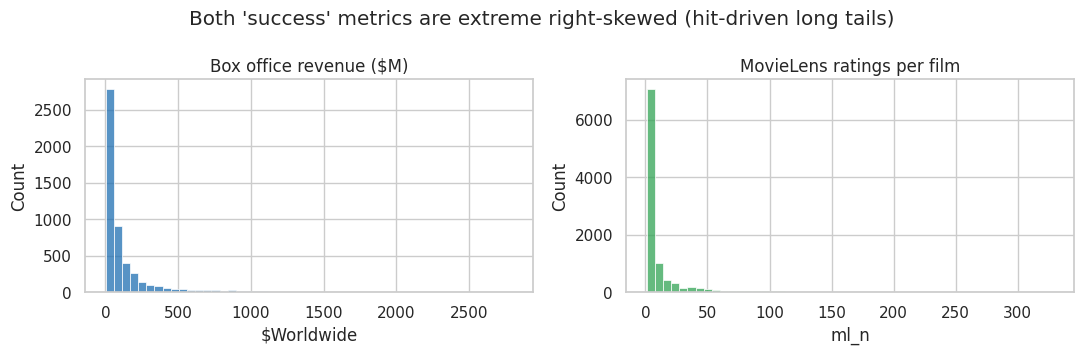

Box office revenue skew: 4.49
MovieLens ratings-per-film skew: 5.24


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.histplot(bo["$Worldwide"]/1e6, bins=50, ax=ax[0], color="#1f6fb2"); ax[0].set_title("Box office revenue ($M)")
sns.histplot(ml_agg["ml_n"], bins=50, ax=ax[1], color="#31a354"); ax[1].set_title("MovieLens ratings per film")
plt.suptitle("Both 'success' metrics are extreme right-skewed (hit-driven long tails)")
plt.tight_layout(); plt.show()

print("Box office revenue skew:", round(bo['$Worldwide'].skew(),2))
print("MovieLens ratings-per-film skew:", round(ml_agg['ml_n'].skew(),2))

## 3. Bivariate — cross-dataset joins by title

In [5]:
def norm(t):
    t = str(t).lower(); t = re.sub(r"\(\d{4}\)","",t); t = re.sub(r"[^a-z0-9 ]","",t)
    return re.sub(r"\s+"," ",t).strip()

bo["key"] = bo["Release Group"].apply(norm)
ml["key"] = ml["title"].apply(norm)
stream["key"] = stream["title"].apply(norm)

bo_ml = bo.merge(ml[["key","ml_n","ml_avg"]].dropna(), on="key", how="inner").drop_duplicates("key")
bo_s  = bo.merge(stream[["key","platform"]].drop_duplicates("key"), on="key", how="inner")
print("Films matched box office <-> MovieLens:", len(bo_ml))
print("Titles matched box office <-> streaming:", bo_s['key'].nunique())

print("\nCross-dataset correlations (matched films):")
print("  box office rating vs MovieLens rating :", round(bo_ml['Rating_num'].corr(bo_ml['ml_avg']),3), "(sources agree)")
print("  log gross vs MovieLens avg rating     :", round(np.log10(bo_ml['$Worldwide']).corr(bo_ml['ml_avg']),3), "(quality != money)")
print("  log gross vs MovieLens # ratings      :", round(np.log10(bo_ml['$Worldwide']).corr(np.log10(bo_ml['ml_n'])),3), "(reach ~ money)")

Films matched box office <-> MovieLens: 1895
Titles matched box office <-> streaming: 1425

Cross-dataset correlations (matched films):
  box office rating vs MovieLens rating : 0.54 (sources agree)
  log gross vs MovieLens avg rating     : 0.099 (quality != money)
  log gross vs MovieLens # ratings      : 0.406 (reach ~ money)


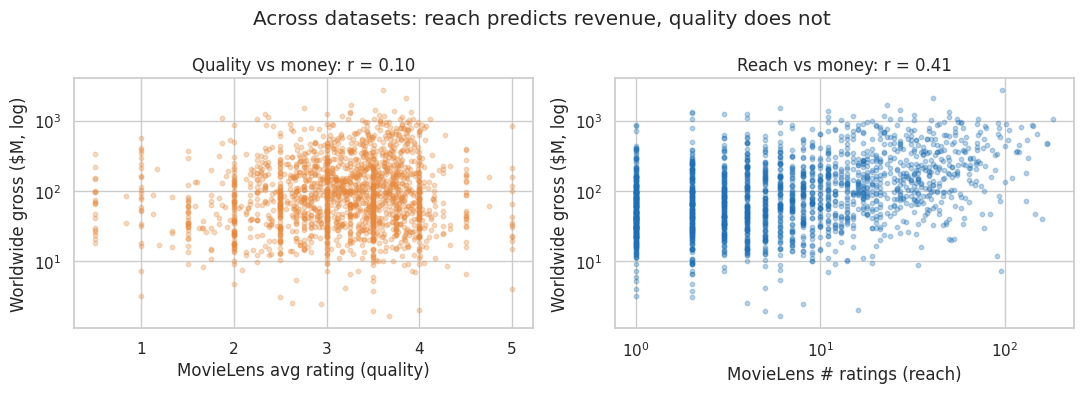

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(bo_ml["ml_avg"], bo_ml["$Worldwide"]/1e6, s=10, alpha=0.3, color="#e6883c"); ax[0].set_yscale("log")
ax[0].set_xlabel("MovieLens avg rating (quality)"); ax[0].set_ylabel("Worldwide gross ($M, log)"); ax[0].set_title("Quality vs money: r = 0.10")
ax[1].scatter(bo_ml["ml_n"], bo_ml["$Worldwide"]/1e6, s=10, alpha=0.3, color="#1f6fb2"); ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("MovieLens # ratings (reach)"); ax[1].set_ylabel("Worldwide gross ($M, log)"); ax[1].set_title("Reach vs money: r = 0.41")
plt.suptitle("Across datasets: reach predicts revenue, quality does not")
plt.tight_layout(); plt.show()

## 4. Platform analysis (streaming-specific)

movie_or_serie  Movie  TV Show
platform                      
amazon-prime     7814     1854
disney           1052      398
hulu             1484     1589
netflix          6131     2676


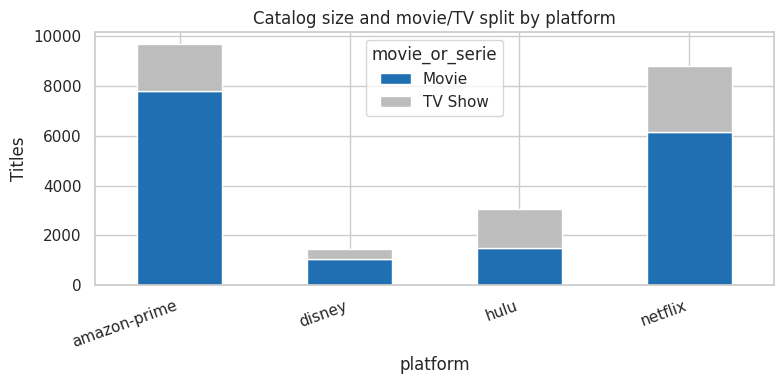


Median release year by platform:
platform
disney          2011.0
amazon-prime    2016.0
hulu            2016.0
netflix         2017.0
Name: release_year, dtype: float64


In [7]:
comp = stream.groupby(["platform","movie_or_serie"]).size().unstack(fill_value=0)
print(comp)
comp.plot.bar(stacked=True, figsize=(8,4), color=["#1f6fb2","#bdbdbd"])
plt.title("Catalog size and movie/TV split by platform"); plt.ylabel("Titles"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

print("\nMedian release year by platform:")
print(stream.groupby("platform")["release_year"].median().sort_values())

## 5. Comparison summary & conclusions

**Structure / granularity.** The three datasets are different *units of observation*: box office is film-level financial, streaming is title-level catalog (multi-platform), and MovieLens is user-level behavioral and must be aggregated. This is the single biggest practical difference — they cannot simply be concatenated; they must be joined on title.

**What replicates across datasets (expected).**
- Ratings are **left-skewed** in both box office and MovieLens — audiences skew generous.
- "Success" metrics are **extreme right-skewed** in both (revenue; ratings-per-film) — the industry is hit-driven.
- Genre mix is broadly **consistent** across all three (Drama/Comedy/Action lead everywhere).
- The two independent rating sources **agree** (box office rating vs MovieLens rating, r = 0.54) — cross-source validation that the ratings measure something real.

**The headline finding (confirmed across datasets).** **Reach predicts revenue; quality does not.** Within box office, Vote_Count vs gross was r = 0.72 and rating vs gross only r = 0.19. Joining to MovieLens reproduces it on an independent source: a film's *number* of MovieLens ratings vs its gross is r = 0.41, but its *average* MovieLens rating vs gross is only r = 0.10. Two datasets, same conclusion.

**Was any dataset disqualified?** No dataset was disqualified, but each contributes different value and none is complete on its own: box office has money but no audience-level behavior; MovieLens has rich behavior but no money and stops in 2018; streaming has distribution but (in this file) no ratings or revenue. The `duration_seconds` mislabeling and the zero-coded ratings were corrected rather than cause for disqualification.

**Suggested supervised/unsupervised analyses.**
- *Supervised:* predict (log) worldwide gross or profitability from pre-release and audience-reach features (vote count, rating count, genre, platform availability). A random forest on the box office features already reaches R² ≈ 0.57; adding MovieLens reach and streaming platform features is the natural next step.
- *Unsupervised:* cluster films/audiences using the MovieLens user-rating matrix (audience segmentation) and cluster titles on the 111-column streaming genre matrix (content-type segmentation); PCA to compress the redundant financial columns.

**Column count:** box office (13) + MovieLens (~14 across 4 tables) + streaming (11 + 111-column genre matrix) is well above the 70-column project minimum.